In [71]:

import os
import yaml
from copy import deepcopy
from functools import partial
from pprint import pprint
from typing import Optional,Literal

import numpy as np
import pandas as pd
import pyreadr as pyr

import matplotlib.pyplot as plt
import seaborn as sns

import optuna

from sklearn.model_selection import cross_validate, KFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import make_scorer, r2_score, root_mean_squared_error, mean_absolute_error, mean_squared_error
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor, BaggingRegressor
from xgboost import XGBRegressor

from IPython.display import clear_output

# Cross-Validation and Optuna 
To improve our models’ predictive performance, we used Optuna, an efficient optimisation tool for tuning hyperparameters. The key idea is to define an objective function, a value that the algorithm tries to minimise during the search, and let Optuna automatically explore combinations of hyperparameters within predefined ranges.

Unlike traditional grid search, Optuna supports multi-objective optimisation. In that case, instead of returning a single best model, it produces a set of non-dominated solutions, also known as the Pareto frontier. When multiple objectives are used, Optuna (by default) applies the NSGA-II algorithm (Non-Dominated Sorting Genetic Algorithm II). This method evolves a population of candidate models and selects the ones that balance the trade-off between objectives (e.g., accuracy vs. overfitting). We suggest to read this [article (GeeksforGeeks)](https://www.geeksforgeeks.org/deep-learning/non-dominated-sorting-genetic-algorithm-2-nsga-ii/) if you want to know more about the search on Non-Dominated Sorting Genetic Algorithm II.

To evaluate each hyperparameter configuration reliably, we apply k-fold cross-validation within Optuna.

- Using the minimum number of folds (e.g. 5) gives less stable estimates.
- Using too many folds (e.g., 10) leaves too little data for validation, which is problematic with the limited data.
We believe that 8-fold cross-validation is a good compromhise balance between computational cost and robustness of the error estimate.

## Custom Objective Functions
During each trial, we optimise two objectives to encourage both accuracy and generalisation:

1. (Output 1 - RMSE) Mean RMSE + 0.5 × Standard Deviation of RMSE

    - Lower mean RMSE = better predictive accuracy across folds.

    - Adding 0.5 × std penalises unstable models whose performance varies too much between folds.

    - We do not want to punish small fluctuations too harshly, however we still prefer stable models and 0.5 should be balanced.

2. (Output 2 - GAP) Mean Train–Validation RMSE Gap + 0.5 × Standard Deviation of the Gap

    - The gap measures overfitting: a large difference between training and validation error indicates poor generalisation.

    - Again, we add 0.5 × std to penalise variability across folds.

    - Minimising this objective helps us select models that perform consistently on unseen data.

We decided to run 7000 trials for each model and pick the hyperparameters of the pareto efficient trial this equation: 0.7*(Output 1 - RMSE) + 0.3*(Output 2 - GAP). The pareto efficient frontier should contain solutions that are accurate, stable and not overfitting; however, we slighly favour the accuracy of the model and we assigned a larger weight (0.7) to the first search parameter. 

For sake of your time, we set prof_qmd=True, so you do not have to rerun the whole study (It can take up to 4 hours). If you want you can clone the [GitHub repository](github.com/LeonSavi/ADS-DW3/) or check the results in the folders.


# Decision Tree Regressor

A **Decision Tree Regressor** predicts numerical values by splitting the dataset into smaller and more homogeneous groups. Each split is based on a feature that minimizes prediction error. Once no further meaningful splits are possible, the model assigns an average value to each terminal node (leaf).

Therefore we believe this model is appropiate for our data: 
- We do not need scaling. Just one Hot encoding should be sufficient.
- Can finds non-linear relationships.
- Works well with small datasets.
- Few assumptions on data
- Control over overfitting with parameters like max_depth, min_samples_leaf, and ccp_alpha pruning, the tree remains generalisable.

## How it works
1. Start at root node.
2. Choose the feature that minimizes a specific error metric (MSE/FriedmanMSE) to split the data.
3. Create child nodes based on the split, where each child represents a subset of the data aligned with the corresponding feature values.
4. Repeat steps 2 and 3 for each child node, continuing to split the data until a stopping condition is reached.
5. Assign a final predicted value to each leaf node, typically the average of the target values in that node.

Hyperparameters we optimise with optuna:
- criterion: function that minimise each split. It can be either Mean Squared Error or Friedman MSE. I understood the difference between MSE and Friedman MSE [here](https://datascience.stackexchange.com/questions/66062/what-is-the-difference-between-freidman-mse-and-mse) 
- max_depth: max depth of the tree prevents excessive growth and overfitting.
- min_samples_split: minimum number of samples required to split a node.
- min_samples_leaf: Minimum number of samples required in a leaf node. The larger this number the smoother are the predictions.
- max_features: number of features considered when splitting to control the randomness and stability in the model.
- ccp_alpha: Cost-Complexity Pruning parameter. Higher values result in more pruning, in other words less diverse outputs.


# AdaBoost Regressor

AdaBoost (Adaptive Boosting) is an ensemble method that combines multiple weak learners (typically shallow Decision Trees) to create a strong predictive model. Instead of training one tree, AdaBoost trains several trees sequentially: each new tree focuses more on the data points where previous trees performed poorly. The final prediction is a weighted sum of all trees.

We believe this model is appropriate for our data because:

- Inherits all the upsides of the our base tree. In our case we try to improve the optimal Decision Tree Regressor model we found earlier .
- The model has a good built-in regularisation to reduce overfitting, i.e. learning rate and number of estimators

## How it works

1. Train the first weak learner (Decision Tree Regressor).
2. Compute its errors on the training data.
3. Increase the weight of incorrectly predicted samples so that the next tree focuses more on them.
4. Train the next tree using the updated sample weights.
5. Repeat this process for N trees, i.e. n_estimators.
6. The final prediction is a weighted average of all trees.

Hyperparameters:
- n_estimators: Number of trees to combine. More estimators can improve performance but also increase overfitting and training time.
- learning_rate: Scales the contribution of each tree. Lower values make learning more stable but require more trees.
- loss: Determines how errors are calculated and reweighted. it can be: "linear", "square" or "exponential".

# Bagging Regressor

The Bagging Regressor (Bootstrap Aggregation) is an ensemble method that improves prediction stability by training multiple Decision Trees models on different bootstrap samples of the training data and averaging their predictions. Unlike AdaBoost, each tree in Bagging is trained independently and with equal importance.

We believe this model is appropriate for our dataset because:

- similarly to ADA, It inherits all the upsides of the our base tree. In our case we try to improve the optimal Decision Tree Regressor we found earlier.
- Less sensitive to noise and outliers than ADA.
- It can prevents overfitting through bootstrapping and by aggregating multiple weak learners.

## How it works

1. Randomly draw multiple bootstrap samples from the training dataset.
2. Train a separate Decision Tree on each bootstrap sample.
3. Optionally sample a random subset of features for each tree (feature bagging).
4. Make predictions by averaging the outputs of all trees.
5. Since trees are independent, this method reduces prediction variance.

Hyperparameters to tune:
- n_estimators:	number of trees to train in the ensemble. More trees usually improve stability.
- max_samples: fraction of training samples drawn for each tree.
- max_features: fraction or number of features used to train each tree. Lower values increase randomness and reduce overfitting.
- bootstrap: whether sampling of data is done with replacement.
- bootstrap_features: Whether features are also sampled with replacement for each tree.
- oob_score: it uses out-of-bag samples to estimate performance without cross-validation. Not used here.

In [72]:
train:pd.DataFrame = pyr.read_r('datasets/train.rds')[None]
rs_seed=1
prof_qmd = True

In [73]:
def ParamXGB(trial):
    '''
    Hyperparameters Search Method for Optuna - XGB model
    '''

    params = {
        "Model__max_depth": trial.suggest_int("Model__max_depth", 2, 12),
        "Model__min_child_weight": trial.suggest_int("Model__min_child_weight", 5, 25),
        "Model__n_estimators": trial.suggest_int("Model__n_estimators", 100, 1000, step=10),
        "Model__learning_rate": trial.suggest_float("Model__learning_rate", 0.01, 0.2, log=True),
        "Model__subsample": trial.suggest_float("Model__subsample", 0.5, 1.0),
        "Model__colsample_bytree": trial.suggest_float("Model__colsample_bytree", 0.5, 1.0),
        "Model__reg_lambda": trial.suggest_float("Model__reg_lambda", 0.1, 10, log=True),
        "Model__reg_alpha": trial.suggest_float("Model__reg_alpha", 0.0, 5.0),
        "Model__gamma": trial.suggest_float("Model__gamma", 0, 5),
    }
    return params


def ParamRF(trial):
    '''
    Hyperparameters Search Method for Optuna - Random Forest model
    '''
    params = {
        "Model__n_estimators": trial.suggest_int("Model__n_estimators", 200, 1200, step=10),
        "Model__max_depth": trial.suggest_categorical(
            "Model__max_depth", [None] + list(range(3, 25))
        ),
        "Model__min_samples_split": trial.suggest_int("Model__min_samples_split", 2, 20),
        "Model__min_samples_leaf": trial.suggest_int("Model__min_samples_leaf", 8, 15),
        "Model__max_features": trial.suggest_categorical("Model__max_features", [
            "sqrt", 0.3, 0.4,0.45,0.5,0.55,0.6,0.7,0.8,0.9,1.0]),
        "Model__max_leaf_nodes": trial.suggest_categorical(
            "Model__max_leaf_nodes", [None] + list(range(40, 201, 5))
        ),
        "Model__min_impurity_decrease": trial.suggest_float(
            "Model__min_impurity_decrease", 0.0, 1e-8
        ),
        "Model__ccp_alpha": trial.suggest_float("Model__ccp_alpha", 0.0, 0.02),
    }

    return params


def ParamDTR(trial):
    '''
    Hyperparameters Search Method for Optuna - Decision Tree Regressor model
    '''
    params = {
        "Model__criterion": trial.suggest_categorical(
            "Model__criterion", ["squared_error", "friedman_mse"]
        ),
        "Model__max_depth": trial.suggest_int("Model__max_depth", 6, 50),
        "Model__min_samples_split": trial.suggest_int("Model__min_samples_split", 4, 30),
        "Model__min_samples_leaf": trial.suggest_int("Model__min_samples_leaf", 4, 30),
        "Model__max_features": trial.suggest_categorical(
            "Model__max_features", [None, "sqrt", 0.3, 0.4, 0.45, 0.5, 0.55, 0.6, 0.7, 0.8, 0.9, 1.0]
        ),
        "Model__ccp_alpha": trial.suggest_float("Model__ccp_alpha", 0, 0.01),
        "Model__min_impurity_decrease": trial.suggest_float("Model__min_impurity_decrease", 1e-6, 0.01,log=True),
    }
    return params


def ParamADA(trial):
    '''
    Hyperparameters Search Method for Optuna - Decision Tree Regressor model w/ADA boost
    '''
    params = {
        "Model__n_estimators": trial.suggest_int("Model__n_estimators", 100, 1200, step=10),
        "Model__learning_rate": trial.suggest_float("Model__learning_rate", 1e-4, 1.0, log=True),
        "Model__loss": trial.suggest_categorical("Model__loss", ['linear', 'square', 'exponential'])
    }
    return params


def ParamBAG(trial):
    """
    Hyperparameters Search Method for Optuna - Bagging Regressor with Decision Tree base estimator
    """
    params = {
        "Model__n_estimators": trial.suggest_int("Model__n_estimators", 50, 1200, step=10),
        "Model__max_samples": trial.suggest_float("Model__max_samples", 0.5, 1.0),
        "Model__max_features": trial.suggest_float("Model__max_features", 0.5, 1.0),
        "Model__bootstrap": trial.suggest_categorical("Model__bootstrap", [True, False]),
        "Model__bootstrap_features": trial.suggest_categorical("Model__bootstrap_features", [False, True])
    }
    return params



In [74]:
class YMLstudy():
    '''
    Homemade Class for to save studies as YML file.
    Display and save Optuna Studies in the folder optuna-study. It creates one if does not exist
    Parameters
    ----------
    model [str]: name of model you are working on

    Returns
    ----------
    None
    '''
    
    def __init__(self, model:str):

        os.makedirs("optuna-study", exist_ok=True)

        self.model = model
        self.file_name = f'{model}-opt_parm.yml'
        self.location = f'optuna-study/{self.file_name}'
        
        if os.path.isfile(self.location):
            self._get_vals()
    
    def read(self, what:Optional[str] = None):

            if what in ['all', None]:
                return self.best_all 
            else:
                return self.best_all[what]


    def write_study(self, study: optuna.Study):
        """
        Save only best_trials to YAML file
        or the efficient frontier in case of multi-optim
        """
        with open(self.location, "w") as writer:
            pareto_data = []
            for t in study.best_trials:
                pareto_data.append({
                    "trial_number": t.number,
                    "values": [round(v, 4) for v in (
                        t.values if isinstance(t.values, (list, tuple)) else [t.value]
                    )],
                    "params": t.params,
                })

            yaml.safe_dump(
                {"best_trials": pareto_data},
                writer,
                default_flow_style=False,
                sort_keys=False,
            )

        self._get_vals()


    def _get_vals(self):
        """
        Load the first best trial from YAML (for quick access).
        the best values will be those in the parato frontier that
        gives the minimum.
        """
        with open(self.location, "r") as loader:
            out = yaml.safe_load(loader)
            self.best_all = out

            best_trials = out.get("best_trials", [])

            if not best_trials:
                self.best_idx = None
                self.best_parameters = None
                self.results = None
                return None

            best_trial = min(best_trials, key=lambda t: 
                0.7*t["values"][0]+0.3*t["values"][1])

            self.best_idx = best_trial["trial_number"]
            self.best_parameters = best_trial["params"]
            self.results = best_trial["values"]
            self.results_sum = sum(best_trial["values"])


def Search(model:Literal['RF', 'DTR', 'XGB', 'ADA', 'BAG'],
           df:pd.DataFrame,
           scores = {
                "RMSE": make_scorer(root_mean_squared_error, greater_is_better=False),
            },
            directions:list[str] = ['minimize'],
            scale:bool=False,
            minimize_gap:bool = True,
            trials:int=1000,
            rs_seed:int=1) -> optuna.study.Study:
            """
            It does Optuna hyperparameter search with preprocessing and cross-validation.
            I added multi-objective tuning, In our case minimize RMSE and GAP. 

            Optional Scaler, optional scaling. Uses YMLstudy to save best trials

            Parameters
            ----------
            model : str
                Model name ('RF', 'DTR', 'ADA','BAG','XGB').
            df : pd.DataFrame
                Input data with features and target column 'score'.
            scores : dict, optional
                Custom scikit-learn scoring dictionary (default: RMSE).
            directions : list[str], optional
                Optimization direction(s). Default: ['minimize'].
            scale : bool, default=False
                Whether to scale numeric features.
            minimize_gap : bool, default=True
                If True, adds a second objective to minimize train–val RMSE gap.
            trials : int, default=1000
                Number of Optuna trials.
            rs_seed : int, default=1

            Returns
            -------
            study : optuna.study.Study
                The completed Optuna study object.
            """
            ml_model,parameters = _modelSelection(model)

            X = deepcopy(df.drop(columns=["score"]))
            y = deepcopy(df["score"])

            cats = X.select_dtypes(include=["object", "category"]).columns.tolist()
            nums = X.select_dtypes(exclude=["object", "category"]).columns.tolist()

            preprocessor = ColumnTransformer([
                ("categorical", OneHotEncoder(sparse_output=False, handle_unknown="ignore"), cats),
                ("numeric", StandardScaler() if scale else "passthrough", nums)
            ])

            pipeline = Pipeline([
                ("preprocessor", preprocessor),
                ("Model", ml_model)
            ])
            ### I need to fix X
            yml = YMLstudy(model)

            study = optuna.create_study(
                    study_name=f"{model}_score",
                    storage="sqlite:///optuna-study/optuna-study.db",
                    directions=directions+(['minimize'] if minimize_gap else []), # multi-objective
                    load_if_exists=True
                )
            objF = partial(OptunaObj,
                        data = (X,y),
                        pipe = pipeline,
                        scores=scores,
                        param=parameters,
                        min_gap = minimize_gap)
            
            study.optimize(objF, n_trials=trials)

            clear_output()

            yml.write_study(study)

            return study

def OptunaObj(
        trial,
        data:tuple,
        pipe:Pipeline,
        scores:dict,
        min_gap:bool,
        param,
        rs_seed:int=1):
    
    '''
    Objective Function for Optuna -> find the hyper parameters that minimize the return
    '''
    
    x,y=data
    print(scores)
    pipe.set_params(**param(trial))

    res = cross_validate(
        estimator=pipe,
        X=x,
        y=y,
        cv=KFold(n_splits=8, shuffle=True, random_state=rs_seed),
        scoring=scores,
        n_jobs=-1,
        verbose=0,
        return_train_score=min_gap
    )
    rmse_fix = -res["test_RMSE"]
    rmse, rmse_std = np.mean(rmse_fix), np.std(rmse_fix) #becase cross_validate
    if min_gap:
        gaps = abs((-res["train_RMSE"])-rmse_fix)
        mean_gap, std_gap = np.mean(gaps), np.std(gaps)
        return rmse+0.5*rmse_std, mean_gap+0.5*std_gap
    else:
        return rmse


def _modelSelection(model):

    dtr_param = {'Model__ccp_alpha': 0.002707026642587006,
       'Model__criterion': 'squared_error',
       'Model__max_depth': 27,
       'Model__max_features': 0.5,
       'Model__min_impurity_decrease': 0.009456029066341605,
       'Model__min_samples_leaf': 7,
       'Model__min_samples_split': 27}

    match model:

        case 'RF':
            ml_model = RandomForestRegressor(bootstrap=True,
                            criterion='squared_error',
                            random_state=rs_seed)
            parameters = ParamRF
        case 'DTR':
            ml_model = DecisionTreeRegressor(splitter="best",
                            max_leaf_nodes=None,
                            random_state=rs_seed)
            parameters = ParamDTR

        case 'XGB':
            ml_model = XGBRegressor(random_state = rs_seed,
                                    grow_policy = 'depthwise')
            parameters = ParamXGB

        case 'ADA':
            ''' Optim pre existing model'''
            if not prof_qmd:
                dtr_param = YMLstudy('DTR').best_parameters

            clean_dtr_par = {k.removeprefix('Model__'):v for k,v in dtr_param.items()}

            dtr_model = DecisionTreeRegressor(
                            splitter="best",
                            max_leaf_nodes=None,
                            random_state=rs_seed
                            ).set_params(**clean_dtr_par)
            ml_model = AdaBoostRegressor(dtr_model,random_state=rs_seed)
            parameters = ParamADA

        case 'BAG':
            if not prof_qmd:
                dtr_param = YMLstudy('DTR').best_parameters

            clean_dtr_par = {k.removeprefix('Model__'):v for k,v in dtr_param.items()}

            dtr_model = DecisionTreeRegressor(
                            splitter="best",
                            max_leaf_nodes=None,
                            random_state=rs_seed
                            ).set_params(**clean_dtr_par)
            ml_model = BaggingRegressor(dtr_model,random_state=rs_seed)
            parameters = ParamBAG


    return ml_model,parameters


def TestModel(
        model:str,
        study_param:dict,
        df:pd.DataFrame,
        scale:bool=False,
        scores:dict = {
                "RMSE": make_scorer(root_mean_squared_error, greater_is_better=False),
                "MSE": make_scorer(mean_squared_error, greater_is_better=False),
                "MAE": make_scorer(mean_absolute_error, greater_is_better=False),
                "R2": make_scorer(r2_score, greater_is_better=True),

            },
        cross_val:bool = True,
        k_splits:int = 5):

    print(f'\n\nUsing best parameter from optuna study for the {model} model: ')
    pprint(study_param)

    ml_model,_ = _modelSelection(model)

    X = deepcopy(df.drop(columns=["score"]))
    y = deepcopy(df["score"])

    cats = X.select_dtypes(include=["object", "category"]).columns.tolist()
    nums = X.select_dtypes(exclude=["object", "category"]).columns.tolist()

    preprocessor = ColumnTransformer([
        ("categorical", OneHotEncoder(sparse_output=False, handle_unknown="ignore"), cats),
        ("numeric", StandardScaler() if scale else "passthrough", nums)
    ])

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("Model", ml_model)
    ]).set_params(**study_param)

    if cross_val:
        cv = cross_validate(
            estimator=pipeline,
            X=X,
            y=y,
            cv=KFold(n_splits=k_splits, shuffle=True, random_state=rs_seed),
            scoring=scores,
            n_jobs=-1,
            verbose=0,
            return_train_score=True
        )

        train_rmse = -cv["train_RMSE"]
        test_rmse = -cv["test_RMSE"]
        gap = abs(train_rmse - test_rmse)


        output = pd.DataFrame(cv).abs().assign(
            model = model,
            gap = gap)
        
        return output
    else:
        model = pipeline.fit(X,y)

        return model
    

def cv_boxplot(concatenated: pd.DataFrame, k:int = 8):
    """
    Creates 6 minimalist boxplots (3 models [test_RMSE, test_R2])
    with numeric y-axis labels only on the leftmost column.
    """

    metrics = ["test_RMSE", "test_R2", 'gap',]
    models = concatenated["model"].unique()
    fig, axes = plt.subplots(len(metrics), len(models), figsize=(10, 9), sharey="row")

    for row, metric in enumerate(metrics):
        for col, model in enumerate(models):
            ax = axes[row, col]
            data = concatenated.loc[concatenated["model"] == model, metric]

            ax.boxplot(
                data,
                vert=True,
                widths=0.35,
                patch_artist=True,
                boxprops=dict(facecolor="0.9", color="black", linewidth=0.9),
                medianprops=dict(color="black", linewidth=1.3),
                whiskerprops=dict(color="black", linewidth=0.9),
                capprops=dict(color="black", linewidth=0.9),
                flierprops=dict(marker=".", markersize=4, color="black", alpha=0.5),
            )

            mean_val = np.mean(data)
            ax.plot(1, mean_val, "o", color="black", markersize=5)

            for spine in ["top", "right"]:
                ax.spines[spine].set_visible(False)
            ax.spines["bottom"].set_linewidth(0.8)
            ax.spines["left"].set_visible(col == 0)
            ax.spines["left"].set_linewidth(0.8 if col == 0 else 0)

            ax.tick_params(axis="x", bottom=False, labelbottom=False)

            if col == 0:
                ax.tick_params(axis="y", labelsize=8, width=0.6)
                ax.set_ylabel(metric.replace("_", " "), fontsize=9, labelpad=8)
            else:
                ax.tick_params(axis="y", left=False, labelleft=False)

            ax.set_title(model, fontsize=9, pad=3)

    plt.suptitle(f"Cross-Validation RMSE and R2 per Model ({k}-fold CV)", fontsize=11, y=1.02)
    plt.tight_layout()
    plt.show()
    if not prof_qmd:
        plt.savefig(f'charts/CV_bbox_k{k}.png')

def plot_gap_rmse(df: pd.DataFrame, k:int =8):
    plt.figure(figsize=(6,5))
    sns.scatterplot(
        data=df,
        x="gap", y="test_RMSE",
        hue="model", s=70, alpha=0.8,
        edgecolor="black", linewidth=0.6
    )

    plt.title(f"Stability vs Accuracy: Gap vs Test RMSE ({k}-fold CV)", fontsize=11)
    plt.xlabel("|Train–Test| RMSE Gap")
    plt.ylabel("Test RMSE")
    plt.legend(frameon=False)
    sns.despine()
    plt.tight_layout()
    if not prof_qmd:
        plt.savefig(f'charts/gap_accuracy_test_k{k}.png')
    plt.show()


def plot_overfitting(concatenated: pd.DataFrame, k:int=8):
    plt.figure(figsize=(6,5))
    sns.scatterplot(
        data=concatenated,
        x="train_RMSE", y="test_RMSE",
        hue="model", style="model",
        s=70, alpha=0.8, edgecolor="black", linewidth=0.6
    )

    l = concatenated[["train_RMSE","test_RMSE"]].min().min()
    m = concatenated[["train_RMSE","test_RMSE"]].max().max()
    plt.plot([l, m], [l, m], 'k--', lw=1, label="Perfect Generalization") # train==test

    plt.title(f"Bias–Variance Check: Train vs Test RMSE ({k}-fold CV)", fontsize=11)
    plt.xlabel("Train RMSE")
    plt.ylabel("Test RMSE")
    plt.legend(frameon=False)
    sns.despine()
    plt.tight_layout()
    if not prof_qmd:
        plt.savefig(f'charts/overfitting_k{k}.png')
    plt.show()


def cv_sum_bars(summ_table: pd.DataFrame, k:int = k):
    metrics = ["test_RMSE", 'test_MSE', 'test_MAE',"test_R2", "gap"]
    fig, axes = plt.subplots(1, len(metrics), figsize=(12, 4))

    for i, metric in enumerate(metrics):
        ax = axes[i]
        means = summ_table[f"mean_{metric}"]
        stds = summ_table[f"std_{metric}"]

        ax.bar(
            summ_table["model"],
            means,
            yerr=stds,
            capsize=4,
            color="0.8",
            edgecolor="black",
            linewidth=0.9
        )
        ax.set_title(metric.replace("_", " "), fontsize=10, pad=5)


    plt.suptitle(f"Cross-Validation Mean w/ Std per Model ({k}-fold CV)", fontsize=11)
    plt.tight_layout()
    if not prof_qmd:
        plt.savefig(f'charts/cv_bars_k{k}.png')
    plt.show()


In [75]:
if not prof_qmd:
    xgb=Search('XGB',train,trials=7000)
    dtr=Search('DTR',train,trials=7000)
    rf=Search('RF',train,trials=7000)
    ada=Search('ADA',train,trials=7000)
    bag=Search('BAG',train,trials=7000)

    print("Best trial for XGB:", YMLstudy('XGB').best_parameters)
    print("Best trial for DTR:", YMLstudy('DTR').best_parameters)
    print("Best trial for RF: ", YMLstudy('RF').best_parameters)
    print("Best trial for ADA:", YMLstudy('ADA').best_parameters)
    print("Best trial for BAG:", YMLstudy('BAG').best_parameters)



if prof_qmd:

       xgb = {'Model__colsample_bytree': 0.9695853263297364,
       'Model__gamma': 1.7721693958288127,
       'Model__learning_rate': 0.04758365155217088,
       'Model__max_depth': 3,
       'Model__min_child_weight': 18,
       'Model__n_estimators': 740,
       'Model__reg_alpha': 2.144839544058323,
       'Model__reg_lambda': 0.1623031425935357,
       'Model__subsample': 0.9396954259072104}


       dtr={'Model__ccp_alpha': 0.002707026642587006,
       'Model__criterion': 'squared_error',
       'Model__max_depth': 27,
       'Model__max_features': 0.5,
       'Model__min_impurity_decrease': 0.009456029066341605,
       'Model__min_samples_leaf': 7,
       'Model__min_samples_split': 27}


       rf ={'Model__ccp_alpha': 0.019921602342457795,
       'Model__max_depth': 7,
       'Model__max_features': 1.0,
       'Model__max_leaf_nodes': None,
       'Model__min_impurity_decrease': 3.526649789908286e-09,
       'Model__min_samples_leaf': 9,
       'Model__min_samples_split': 20,
       'Model__n_estimators': 310}


       ada = {'Model__learning_rate': 0.0026531242369260627,
       'Model__loss': 'exponential',
       'Model__n_estimators': 100}


       bag = {'Model__bootstrap': True,
       'Model__bootstrap_features': False,
       'Model__max_features': 0.9869871649037336,
       'Model__max_samples': 0.8654585236460131,
       'Model__n_estimators': 60}

# MODEL COMPARISON

In [76]:
k = 8
xgb_fin = TestModel('XGB',
          study_param = xgb if prof_qmd else YMLstudy('XGB').best_parameters,
          df=train,
          k_splits=k)

dtr_fin = TestModel('DTR',
          study_param = dtr if prof_qmd else YMLstudy('DTR').best_parameters,
          df=train,
          k_splits=k)

rf_fin = TestModel('RF',
          study_param = rf if prof_qmd else YMLstudy('RF').best_parameters,
          df=train,
          k_splits=k)

ada_fin = TestModel('ADA',
          study_param = ada if prof_qmd else YMLstudy('ADA').best_parameters,
          df=train,
          k_splits=k)

bag_fin = TestModel('BAG',
          study_param = bag if prof_qmd else YMLstudy('BAG').best_parameters,
          df=train,
          k_splits=k)

concatenated = pd.concat([xgb_fin,rf_fin,dtr_fin,ada_fin,bag_fin],axis=0).reset_index(drop=True)





Using best parameter from optuna study for the XGB model: 
{'Model__colsample_bytree': 0.9695853263297364,
 'Model__gamma': 1.7721693958288127,
 'Model__learning_rate': 0.04758365155217088,
 'Model__max_depth': 3,
 'Model__min_child_weight': 18,
 'Model__n_estimators': 740,
 'Model__reg_alpha': 2.144839544058323,
 'Model__reg_lambda': 0.1623031425935357,
 'Model__subsample': 0.9396954259072104}


Using best parameter from optuna study for the DTR model: 
{'Model__ccp_alpha': 0.002707026642587006,
 'Model__criterion': 'squared_error',
 'Model__max_depth': 27,
 'Model__max_features': 0.5,
 'Model__min_impurity_decrease': 0.009456029066341605,
 'Model__min_samples_leaf': 7,
 'Model__min_samples_split': 27}


Using best parameter from optuna study for the RF model: 
{'Model__ccp_alpha': 0.019921602342457795,
 'Model__max_depth': 7,
 'Model__max_features': 1.0,
 'Model__max_leaf_nodes': None,
 'Model__min_impurity_decrease': 3.526649789908286e-09,
 'Model__min_samples_leaf': 9,
 'Model__m

In [77]:
# get results
cols=[col for col in concatenated.columns if col not in ['fit_time','score_time','model']]
summ_table = (concatenated
         .pivot_table(index='model',
                      values=cols,
                      aggfunc=['mean', 'std'])
         .round(4))
summ_table.columns = [f"{s}_{m}" for s,m in summ_table.columns]

summ_table.reset_index(inplace=True)
if not prof_qmd:
    with pd.ExcelWriter('outputs/cv_results.xlsx') as w:
        summ_table.to_excel(w,sheet_name=f'k_{k}',index=False)

In [78]:
mean_col = [col for col in summ_table.columns if col.startswith('mean')]
std_col  = [col for col in summ_table.columns if col.startswith('std')]

print('\nSummary of CV: MEAN\n')
display(summ_table[['model']+mean_col])

print('\nSummary of CV: STD\n')
display(summ_table[['model']+std_col])



Summary of CV: MEAN



,model,mean_gap,mean_test_MAE,mean_test_MSE,mean_test_R2,mean_test_RMSE,mean_train_MAE,mean_train_MSE,mean_train_R2,mean_train_RMSE
0,ADA,0.1784,0.6553,0.7292,0.2454,0.8398,0.5167,0.4535,0.5320,0.6733
1,BAG,0.1552,0.6679,0.7445,0.2299,0.8494,0.5882,0.5779,0.4037,0.7600
2,DTR,0.0976,0.6958,0.7480,0.2046,0.8610,0.6161,0.6099,0.3710,0.7805
3,RF,0.1450,0.6572,0.7231,0.2492,0.8366,0.5821,0.5646,0.4173,0.7512
4,XGB,0.1380,0.6711,0.7381,0.2306,0.8474,0.5904,0.5753,0.4062,0.7583



Summary of CV: STD



,model,std_gap,std_test_MAE,std_test_MSE,std_test_R2,std_test_RMSE,std_train_MAE,std_train_MSE,std_train_R2,std_train_RMSE
0,ADA,0.1685,0.1336,0.2909,0.1305,0.1651,0.0135,0.0229,0.0156,0.0173
1,BAG,0.1213,0.1408,0.2816,0.1116,0.1619,0.0164,0.0313,0.0199,0.0208
2,DTR,0.0972,0.0748,0.1576,0.1475,0.0880,0.0249,0.0440,0.0312,0.0286
3,RF,0.1331,0.1367,0.2848,0.1415,0.1632,0.0167,0.0313,0.0236,0.0212
4,XGB,0.1223,0.1267,0.2624,0.1112,0.1511,0.0152,0.0254,0.0181,0.0169


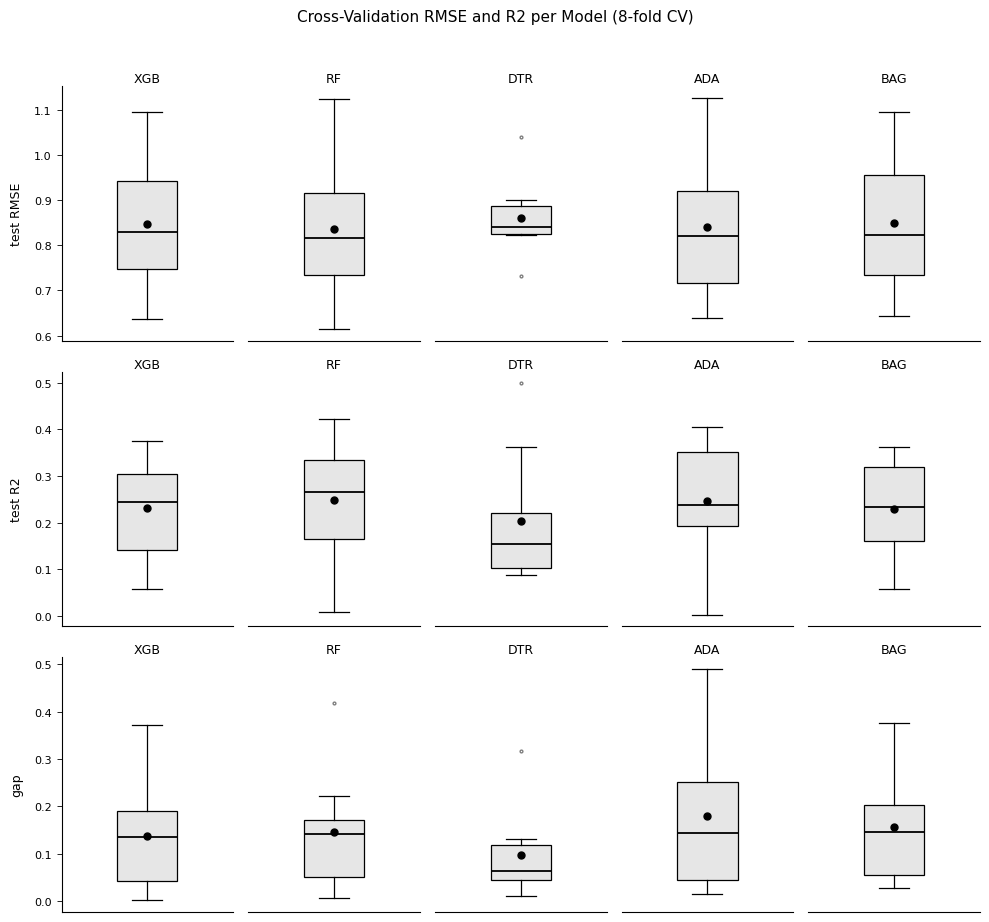

In [79]:
cv_boxplot(concatenated)

# Bias-Variance
The chart below assesses whether models are overfitting or generalising well by comparing their training and test RMSE scores. Each point represents a model during CV: if it lies close to the dashed diagonal line, it means the model performs similarly on both the training and test data, which means that is generalised well. Therefore, points below the line suggest underfitting, while points above indicates overfitting, where the model performs well on training data but poorly on unseen data. Overall, the plot gives us insights about the bias–variance trade-off across different models. 
In our case the most striking insights are:
- DTR: very close to the diagonal but mostly above the line.
- RF: three observations on the diagonal, but others are mostly overfitting.
- ADA: compared to other models has much lower training performance, but higher on validation. Overall a lot of overfitting 
- XGB/BAG: Similar to RF.

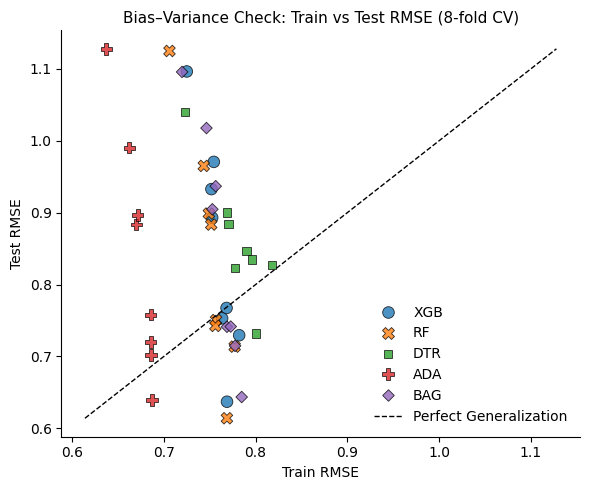

In [80]:
plot_overfitting(concatenated)

# Stability VS Accuracy

This chart evaluates the trade-off between a model’s stability and accuracy, therefore we evaluate the work of our optuna objective function. We plot the absolute gap between train and test RMSE against the test RMSE. As said earlier, a lower gap indicates a more stable model with consistent performance across train and test data, while a lower test RMSE reflects higher predictive accuracy. Perfect models should be in the bottom-left area, where both the error and the gap are small. Points farther away indicate models that are either unstable or inaccurate. 
In our case we see:
- DTR: best with low gap and RMSE in most of the folds, suggesting higher reliability.
- RF: Noticebily, has some validation tests with both lower gap and RMSE than DTR, but in other cases show higher gaps and RMSE. However still acceptable in most cases
- XGB/BAG: Follow a pattern similar to RF, but with sometimes better results
- ADA: Often always lower RMSE and GAP compared to other models still many tests with high gaps and RMSE.


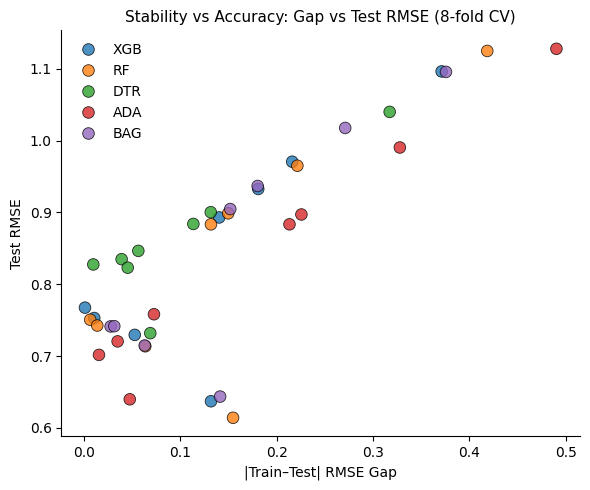

In [81]:
plot_gap_rmse(concatenated)

# FINAL OUT OF SAMPLE VALIDATION
To have a less foggy picture of the results (especially for DTR and RF), I need to make some further checks. Given the limited train data, I decided to mesure robustness of the models and hyperparameter by increasng the number of folds from 8 to 10.

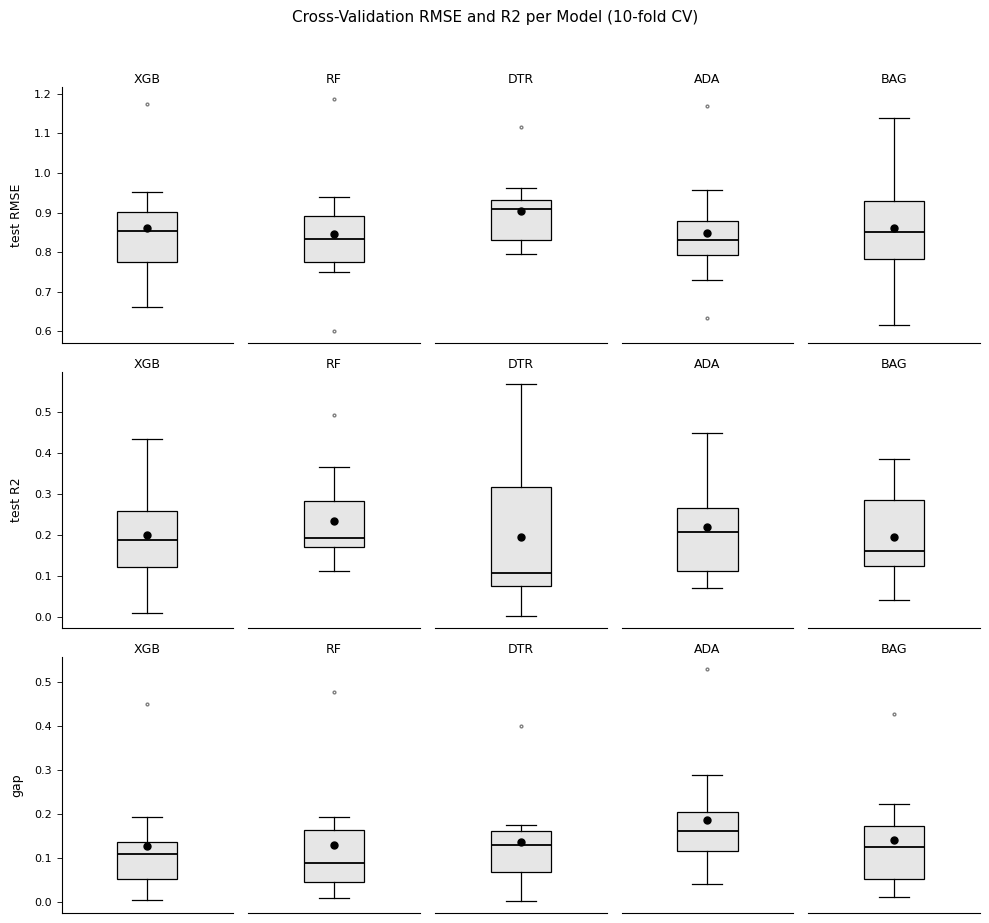

In [82]:

k = 10

xgb_fin = TestModel('XGB',
          study_param = xgb if prof_qmd else YMLstudy('XGB').best_parameters,
          df=train,
          k_splits=k)

dtr_fin = TestModel('DTR',
          study_param = dtr if prof_qmd else YMLstudy('DTR').best_parameters,
          df=train,
          k_splits=k)

rf_fin = TestModel('RF',
          study_param = rf if prof_qmd else YMLstudy('RF').best_parameters,
          df=train,
          k_splits=k)

ada_fin = TestModel('ADA',
          study_param = ada if prof_qmd else YMLstudy('ADA').best_parameters,
          df=train,
          k_splits=k)

bag_fin = TestModel('BAG',
          study_param = bag if prof_qmd else YMLstudy('BAG').best_parameters,
          df=train,
          k_splits=k)

concatenated = pd.concat([xgb_fin,rf_fin,dtr_fin,ada_fin,bag_fin],axis=0).reset_index(drop=True)
clear_output()
cv_boxplot(concatenated,k=10) #k=10 to save results


In [83]:
# get results
cols=[col for col in concatenated.columns if col not in ['fit_time','score_time','model']]
summ_table = (concatenated
         .pivot_table(index='model',
                      values=cols,
                      aggfunc=['mean', 'std'])
         .round(4))
summ_table.columns = [f"{s}_{m}" for s,m in summ_table.columns]

summ_table.reset_index(inplace=True)
if not prof_qmd:
    with pd.ExcelWriter('outputs/cv_results_k10.xlsx') as w:
        summ_table.to_excel(w,sheet_name=f'k_{k}',index=False)

# Table Results

- DTR: as we increase the number of folds, this model shows worse results than before. Mean R2 increases along with its MSE. Performing significantly worse than other competitors.
- RF: In spite of higher volatility, mean metrics look overall better than other models.


Summary of CV: MEAN



,model,mean_gap,mean_test_MAE,mean_test_MSE,mean_test_R2,mean_test_RMSE,mean_train_MAE,mean_train_MSE,mean_train_R2,mean_train_RMSE
0,ADA,0.1864,0.6638,0.7398,0.2198,0.8494,0.5137,0.4523,0.5331,0.6724
1,BAG,0.1398,0.6745,0.7580,0.1957,0.8599,0.5845,0.5730,0.4086,0.7568
2,DTR,0.1362,0.7353,0.8258,0.1967,0.9044,0.6040,0.5907,0.3904,0.7682
3,RF,0.1295,0.6637,0.7365,0.2351,0.8460,0.5814,0.5649,0.4169,0.7515
4,XGB,0.1266,0.6771,0.7589,0.2015,0.8612,0.5904,0.5764,0.4050,0.7591



Summary of CV: STD



,model,std_gap,std_test_MAE,std_test_MSE,std_test_R2,std_test_RMSE,std_train_MAE,std_train_MSE,std_train_R2,std_train_RMSE
0,ADA,0.1418,0.1017,0.2612,0.1305,0.1428,0.0074,0.0175,0.0164,0.0132
1,BAG,0.1223,0.1054,0.2542,0.1161,0.1440,0.0103,0.0237,0.0211,0.0160
2,DTR,0.1077,0.0875,0.1773,0.1878,0.0930,0.0215,0.0367,0.0366,0.0242
3,RF,0.1372,0.1068,0.2767,0.1189,0.1517,0.0108,0.0227,0.0218,0.0154
4,XGB,0.1274,0.0998,0.2571,0.1210,0.1387,0.0099,0.0204,0.0222,0.0136


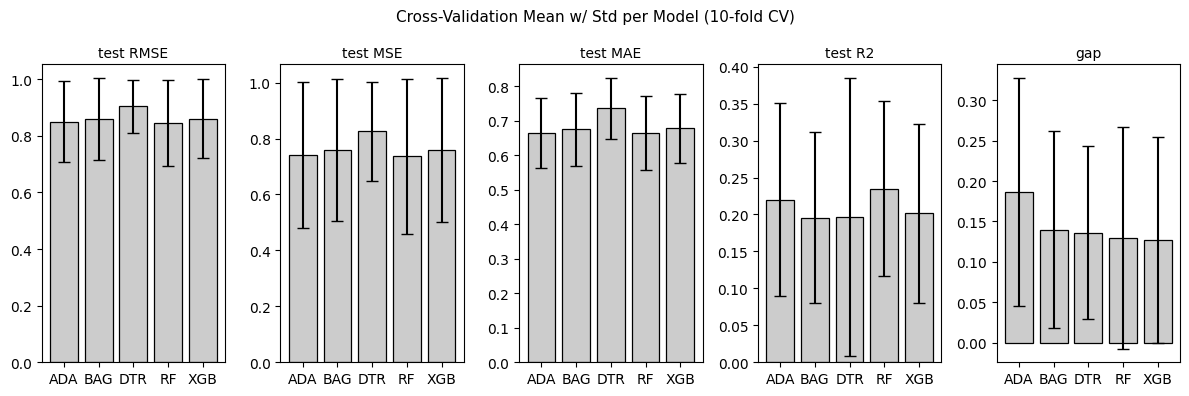

In [84]:
mean_col = [col for col in summ_table.columns if col.startswith('mean')]
std_col  = [col for col in summ_table.columns if col.startswith('std')]

print('\nSummary of CV: MEAN\n')
display(summ_table[['model']+mean_col])

print('\nSummary of CV: STD\n')
display(summ_table[['model']+std_col])

cv_sum_bars(summ_table,k=10)

# Overfitting

- DTR: overall we notice a stronger tendency to overfit, probably due to the depth (max_depth = 27), suggesting that probably further exploration for lower values is needed. However overall close to generalization line.
-  RF: Many samples are close to the generalization line. Suggesting better overall genralization than other models

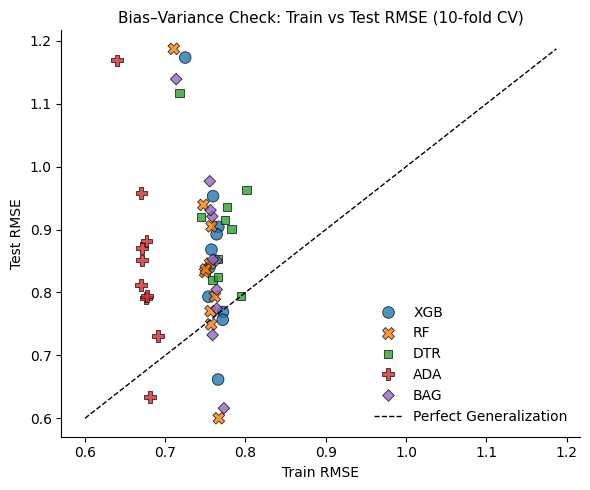

In [85]:

plot_overfitting(concatenated, k=10)


# Model Choice
In our work we were confused on whether we should use DTR or RF.
- DTR: when k=8 shows overall less overfitting, fairly good MSE and tight volatilty. However the R2 is smaller than competitors, suggesting the can explain way less. However, when k=10, we see a lack of consistency in the results with a strong tendency to overfit, along with larger mean MSE (~10 basis points difference) and much larger volatily in R2.
- RF: when k=8, the RF has the lowest mean MSE (0.72), but with arguably high std. However, it performs similarly to BAG and XGB with a mean gap of 0.145, much higher than the 0.0976 achieved by DTR. The situation changes as we switch to k=10. The mean MSE and std both increase slightly of about 1bps, but remains the lowest average across models. R2 only slightly decreases, from approx 0.25 to 0.235, still remaining the highest value among the competitors. Surprisingly Gap distance overall narrowed, bias-variance check shows many cross validation values close to generalization line, i.e. at least 6 samples out of 10 have less than 10% difference.
- XGB: if k=8. even if it has similar perfamance of RF, for what regards RMSE/MAE/MSE but with overall less volatility, it didnt stand out for us. Compared to the two previous models, XGB shows longer wiskers in the gap, and lower average R2 than RF. When we change the number of folds to k=10, the mean MSE increases more compared to the others and R2 worsen (from 0.23 to 0.2) and slightly higher std compared to RF. However, the GAP is slightly better than RF. both in terms of mean and std.
- ADA/BAG: Even if both models offer improved performance in MSE, they did not stand out for us. ADA, in both final cross-validation tests (k=10 and k=8 we get higher) large wiskers in the box plots and strong overfitting. BAG didn't offer any significant improvement, except for lower gap when we switch to 10 folds, but still lower R2.

For the above reasons we believe that the Random Forest is a good fit with the selected Hyperparameter is good fit for the task. Further tuning in optuna search can further improve our results. You can look at our [Github repository](https://github.com/LeonSavi/ADS-DW3/) to see more outputs, like CSVs, R codes, other models (a failed Deep Learning model), Optuna Databases (.db) or YML files with the best trials (efficient frontier).  

In [86]:
# train best model RF

X_test = pyr.read_r('datasets/test.rds')[None]

rf_model = TestModel('RF',
          study_param = dtr if prof_qmd else YMLstudy('RF').best_parameters,
          df=train,
          cross_val=False)

predictions = pd.DataFrame(rf_model.predict(X_test))
pyr.write_rds('datasets/predictions.rds',predictions)



Using best parameter from optuna study for the RF model: 
{'Model__ccp_alpha': 0.002707026642587006,
 'Model__criterion': 'squared_error',
 'Model__max_depth': 27,
 'Model__max_features': 0.5,
 'Model__min_impurity_decrease': 0.009456029066341605,
 'Model__min_samples_leaf': 7,
 'Model__min_samples_split': 27}
